#  Flood detection with Sentinel-1

Using images from Sentinel-1, a European Space Agency (ESA) radar satellite, is highly effective for analysing flooded areas. Thanks to its synthetic aperture radar (SAR) technology, Sentinel-1 can capture images of the Earth’s surface in any weather condition and during the day or night. This is particularly useful for monitoring floods, as it makes it possible to detect surface changes, such as rising water levels, even under dense clouds or in hard-to-reach places. In addition, SAR images can differentiate between wet and dry surfaces, facilitating the accurate identification of flood-affected areas, which is crucial for disaster mitigation, planning and response actions.

Let's install the Rasterio

In [ ]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 22.9 MB/s eta 0:00:00


Now we authenticate the Google Earth Engine API for Python with the access key we received when logging in with the email registered in GEE:

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='my-project-1527255156007')

We will do the same with Drive. It is essential to use the same Gmail account for GEE and Drive/Colab authentication:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Let's import the packages:

In [ ]:
import folium
from folium import plugins
from IPython.display import Image
import rasterio
import numpy as np
from matplotlib import pyplot as plt
import cv2

Let's delimit a study area and use boundary coordinates to use in our example:

In [ ]:
AOI = ee.Geometry.Polygon(
        [[[-51.892181302540386, -29.759013206170284],
          [-51.892181302540386, -30.15640888220445],
          [-51.076446439259136, -30.15640888220445],
          [-51.076446439259136, -29.759013206170284]]])

The next step is to select the start and end dates of the flood event and a time when the water level is within normal limits:

In [ ]:
startDate_wet = ee.Date.fromYMD(2024,4,29);
endDate_wet = ee.Date.fromYMD(2024,5,20);

In [ ]:
startDate_dry = ee.Date.fromYMD(2023,10,29);
endDate_dry = ee.Date.fromYMD(2023,12,20);

In [ ]:
collection_S1_wet = ee.ImageCollection('COPERNICUS/S1_GRD').filter(ee.Filter.eq('instrumentMode', 'IW')).filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).filterBounds(AOI).filterDate(startDate_wet,endDate_wet).select(['VV','VH']);
collection_S1_dry = ee.ImageCollection('COPERNICUS/S1_GRD').filter(ee.Filter.eq('instrumentMode', 'IW')).filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).filterBounds(AOI).filterDate(startDate_dry,endDate_dry).select(['VV','VH']);

Then we select the median mosaic from the existing images and set the display parameters:

In [ ]:
S1_wet = collection_S1_wet.median().clip(AOI)
S1_dry = collection_S1_dry.median().clip(AOI)
vis_params = {'min': -20, 'max': 7}

Here we define some basemaps to use in Folium:

In [ ]:
basemaps = {
    'Google Satellite': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Satellite',
        overlay = True,
        control = True
    ),
    'Google Terrain': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Terrain',
        overlay = True,
        control = True
    )}

The add_ee_layer function will make it easy to add vector and image layers to Folium:

In [ ]:
def add_ee_layer(self, ee_object, vis_params, name):

    try:
        # display ee.Image()
        if isinstance(ee_object, ee.image.Image):
            map_id_dict = ee.Image(ee_object).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
        # display ee.ImageCollection()
        elif isinstance(ee_object, ee.imagecollection.ImageCollection):
            ee_object_new = ee_object.mosaic()
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
        # display ee.Geometry()
        elif isinstance(ee_object, ee.geometry.Geometry):
            folium.GeoJson(
            data = ee_object.getInfo(),
            name = name,
            overlay = True,
            control = True
        ).add_to(self)
        # display ee.FeatureCollection()
        elif isinstance(ee_object, ee.featurecollection.FeatureCollection):
            ee_object_new = ee.Image().paint(ee_object, 0, 2)
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
        ).add_to(self)

    except:
        print("Could not display {}".format(name))

# Add EE drawing method to folium.
folium.Map.add_ee_layer = add_ee_layer

We can then show the VV and VH polarizations of the S1 images from the two selected epochs.

In [ ]:
my_map = folium.Map(location=[-30.15640888220445,
                            -51.076446439259136], zoom_start=10)

# Add custom basemaps
basemaps['Google Terrain'].add_to(my_map)

# Add the elevation model to the map object.
my_map.add_ee_layer(S1_wet.select('VV'), vis_params, 'VV_wet')
my_map.add_ee_layer(S1_wet.select('VH'), vis_params, 'VH_wet')
my_map.add_ee_layer(S1_dry.select('VV'), vis_params, 'VV_dry')
my_map.add_ee_layer(S1_dry.select('VH'), vis_params, 'VH_dry')
my_map.add_child(folium.LayerControl())

# Display the map.
display(my_map)

Now we can download the images to the Drive so that we can open them as a numpy array. First, let's select the bands we will use, as well as the resolution and the coordinate system:

In [ ]:
image_wet = S1_wet.select(['VV', 'VH']).reproject('EPSG:4326', None, 20)
image_dry = S1_dry.select(['VV', 'VH']).reproject('EPSG:4326', None, 20)

Finally, we can download our images:

In [ ]:
task_wet = ee.batch.Export.image.toDrive(image=image_wet,
                                         crs='EPSG:4326',
                                         scale=20,
                                         fileFormat='GeoTIFF',
                                         description='S1_RS_wet' ,
                                         maxPixels=1e13,
                                         region= AOI)

In [ ]:
task_wet.start()

In [ ]:
task_dry = ee.batch.Export.image.toDrive(image=image_dry,
                                         crs='EPSG:4326',
                                         scale=20,
                                         fileFormat='GeoTIFF',
                                         description='S1_RS_dry' ,
                                         maxPixels=1e13,
                                         region= AOI)

In [ ]:
task_dry.start()

After checking in Drive if the images are stored, let's import the files with the raster and convert them into numpy arrays:

In [ ]:
path_S1_wet = '/content/drive/MyDrive/Datasets_CV/S1_RS_wet.tif'
path_S1_dry = '/content/drive/MyDrive/Datasets_CV/S1_RS_dry.tif'

In [ ]:
src_S1_wet = rasterio.open(path_S1_wet)
src_S1_dry = rasterio.open(path_S1_dry)

In [ ]:
img_VV_wet = src_S1_wet.read(1)
img_VH_wet = src_S1_wet.read(2)

img_VV_dry = src_S1_dry.read(1)
img_VH_dry = src_S1_dry.read(2)

Let's preprocess the images using the Lee filter.

In [ ]:
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.filters import threshold_otsu
import skimage
import seaborn as sns
from scipy.ndimage import uniform_filter
from scipy.ndimage import variance

In [ ]:
img_VH_dry = np.nan_to_num(img_VH_dry)
img_VV_dry = np.nan_to_num(img_VV_dry)

img_VH_wet = np.nan_to_num(img_VH_wet)
img_VV_wet = np.nan_to_num(img_VV_wet)



In [ ]:
def lee_filter(img, size):
    img_mean = uniform_filter(img, (size, size))
    img_sqr_mean = uniform_filter(img**2, (size, size))
    img_variance = img_sqr_mean - img_mean**2
    overall_variance = variance(img)
    img_weights = img_variance**2 / (img_variance**2 + overall_variance**2)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output

In [ ]:
img_VH_dry = lee_filter(img_VH_dry, 7)
img_VV_dry = lee_filter(img_VV_dry, 7)

img_VH_wet = lee_filter(img_VH_wet, 7)
img_VV_wet = lee_filter(img_VV_wet, 7)

Let's use the SWI index for both periods:

In [ ]:
SWI_wet = (img_VV_wet*0.1747) + (img_VH_wet*img_VV_wet*0.0082) + ((img_VV_wet**2)*0.0023) - ((img_VH_wet**2)*0.0015) + (0.1904)

SWI_dry = (img_VV_dry*0.1747) + (img_VH_dry*img_VV_dry*0.0082) + ((img_VV_dry**2)*0.0023) - ((img_VH_dry**2)*0.0015) + (0.1904)

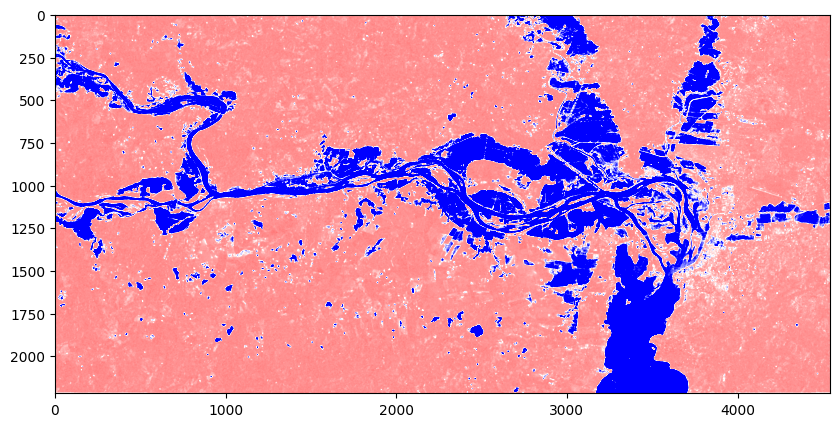

In [ ]:
plt.figure(figsize=[10,10])
plt.imshow(SWI_wet, vmin=-1, vmax=1, cmap='bwr_r')

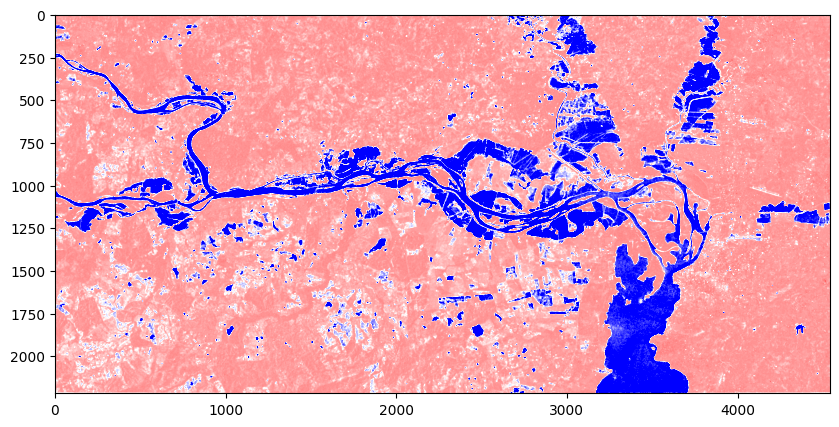

In [ ]:
plt.figure(figsize=[10,10])
plt.imshow(SWI_dry, vmin=-1, vmax=1, cmap='bwr_r')

We will apply the otsu threshold to divide the image into two classes: flooded area and non-flooded area.

In [ ]:
thresh_dry = threshold_otsu(SWI_dry)
thresh_wet = threshold_otsu(SWI_wet)
print("Otsu's threshold value:", thresh_dry)
print("Otsu's threshold value:", thresh_wet)

Otsu's threshold value: 0.40084059968890207
Otsu's threshold value: 0.657763146775737


In [ ]:
binary_img_wet = SWI_wet > thresh_wet
binary_img_dry = SWI_dry > thresh_dry

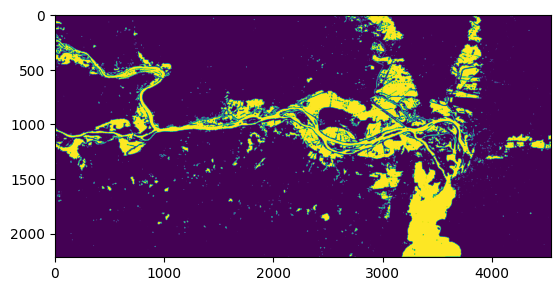

In [ ]:
plt.imshow(binary_img_wet)

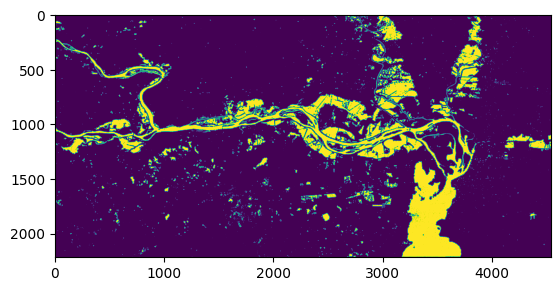

In [ ]:
plt.imshow(binary_img_dry)

In [ ]:
binary_img_wet = binary_img_wet.astype('uint8')
binary_img_dry = binary_img_dry.astype('uint8')

Now let's look at the difference between the image after the flood and before the flood:

In [ ]:
diff_img = binary_img_wet - binary_img_dry

In [ ]:
np.unique(diff_img)

array([  0,   1, 255], dtype=uint8)

In [ ]:
diff_img = np.where(diff_img == 1, 1, 0)

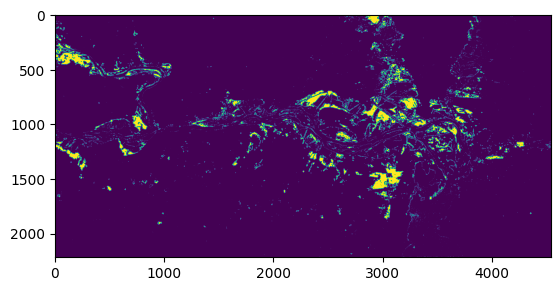

In [ ]:
plt.imshow(diff_img)

Finally we can save the image in a raster file:

In [ ]:
out_meta = src_S1_wet.meta.copy()
out_meta.update({"driver": "GTiff",
                  "compress":'lzw',
                  "dtype": 'uint8',
                  "count":1
                  })

In [ ]:
with rasterio.open('/content/mapa.tif', "w", **out_meta) as dest:
     dest.write(diff_img[np.newaxis,:])